In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from Tracer import solver, initial_velocity, initial_spin_rate, WindField
import Tracer.debug_tools as d

In [ ]:
from Tracer.tracer import fetch_wind_data, acc
from scipy.integrate import solve_ivp

def odesystem(t, y, W_initial, wind, decay_rate):
    # 1. Unpack the state
    P = y[:3]
    V = y[3:]
    
    # 2. Update Spin (Decay is time-dependent)
    W = W_initial * np.exp(-decay_rate * t)
    
    # 3. Get Acceleration
    # (Assuming fetch_wind_data and acc are accessible)
    wind_vec = fetch_wind_data(wind, *P)
    a = acc(V, W, wind_vec)
    
    # 4. Return derivatives: [velocity_x, y, z, acceleration_x, y, z]
    return np.concatenate([V, a])

# Define the 'Ground Hit' event to stop the solver early

def hit_ground(t, y, *args):
    return y[2] # The Z-coordinate
hit_ground.terminal = True
hit_ground.direction = -1

def solver_rk45(V0, W0, P0=np.array([0, 0, 0]), wind=None, dt=0.05, decay_rate=0.05, mt=15, rtol=1e-5):
    # Similar setup as above but with fixed time steps
    # Initial state: Combine P0 and V0
    y0 = np.concatenate([P0, V0])

    if wind is None:
        wind = WindField(nx=300, ny=50, nz=50, direction=45, profile='log', z0=0.003, U_ref=6) # default wind field if none provided

    t_requested = np.arange(0, mt + dt, dt) if dt else None

    sol = solve_ivp(
        odesystem, 
        t_span=(0, mt),       # Max time 15 seconds
        y0=y0, 
        method='RK45',        # Dormand-Prince adaptive solver
        args=(W0, wind, decay_rate),
        events=hit_ground,    # Stops the moment Z hits 0
        t_eval=t_requested,
        rtol=rtol, atol=rtol/1000  # Precision settings
    )

    # Accessing results:
    t_steps = sol.t
    positions = sol.y[:3, :].T # Shape (N, 3)
    velocities = sol.y[3:, :].T
    spin_rates = W0 * np.exp(-decay_rate * t_steps[:, np.newaxis])

    return t_steps, positions, velocities, spin_rates, sol.nfev



In [ ]:
V0 = initial_velocity(40, 25) # 40 m/s at 25 degrees
W0 = initial_spin_rate(8500) # 8500 rpm

In [ ]:
d.plot_trajectories([solver_rk45(V0, W0)[:4]])

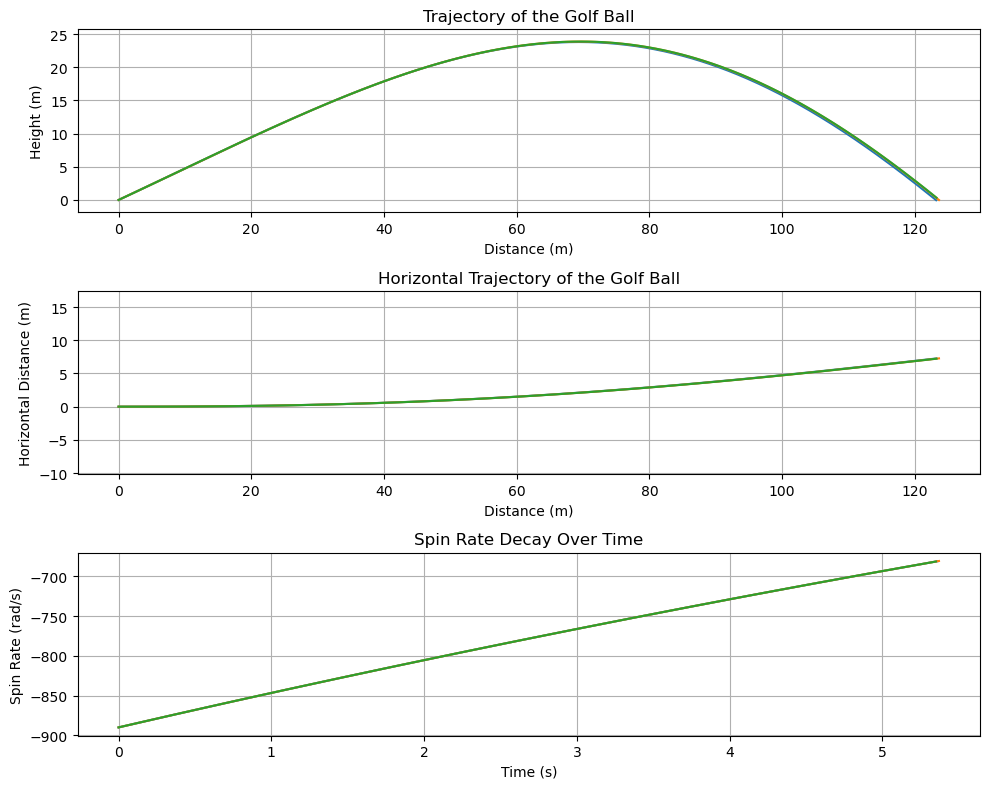

In [ ]:
ax = d.plot_trajectories([solver(V0, W0, dt=0.01), solver(V0, W0, dt=0.001), solver_rk45(V0, W0, dt=0.05)[:4], solver_rk45(V0, W0)[:4]])
plt.show()


In [75]:
def run_convergence_test(truth, dts, tols):
    # 1. Euler Test: Varying dt
    n_evals_euler = []
    errors_euler = []

    # 2. RK45 Test: Varying rtol (Relative Tolerance)
    # This is how you "ask" RK45 to be more precise
    n_evals_rk45 = []
    errors_rk45 = []

    print(f"Running convergence tests [{len(dts)} dt values]")
    for d in dts:
        p_e = solver(V0, W0, dt=d)[1] # Your manual Euler
        errors_euler.append(np.linalg.norm(p_e[-1] - truth))
        n_evals_euler.append(len(p_e))
        print('.', end='') # Progress indicator

    print(f"\nRunning convergence tests [{len(tols)} rtol values]")
    for t in tols:
        t_r, p_r, v_r, w_r, n_e = solver_rk45(V0, W0, rtol=t, dt=None)
        errors_rk45.append(np.linalg.norm(p_r[-1] - truth))
        n_evals_rk45.append(n_e) # Now n_e will change!
        print('.', end='') # Progress indicator

    return n_evals_euler, errors_euler, n_evals_rk45, errors_rk45, dts, tols

def plot_convergence(n_evals_euler, errors_euler, n_evals_rk45, errors_rk45, dts, tols):
    plt.figure(figsize=(10, 6))
    
    # Plot Error vs Work
    plt.loglog(n_evals_euler, errors_euler, 'o-', label='Euler (Varying dt)')
    annotations_dt = [(n_evals_euler[i], errors_euler[i], f'dt={dts[i]:.0e}') for i in range(len(dts))]

    plt.loglog(n_evals_rk45, errors_rk45, 's-', label='RK45 (Varying rtol)')
    annotations_rtol = [(n_evals_rk45[i], errors_rk45[i], f'tol={tols[i]:.0e}') for i in range(len(tols))]
    
    for x, y, text in annotations_rtol + annotations_dt:
        plt.annotate(text, (x, y), textcoords="offset points", xytext=(0,10), ha='left')

    # Labels for clarity
    plt.title("Efficiency Comparison: Which solver is 'smarter'?")
    plt.xlabel("Computational Effort (Total Function Evaluations) [log]")
    plt.ylabel("Final Position Error [log]")
    
    # Custom Y-ticks for human readability
    plt.yticks([1e-9, 1e-6, 1e-3, 1, 1e3], ['1 nm', '1 µm', '1 mm', '1 m', '1 km'])
    plt.xlim(right=np.max([np.max(n_evals_rk45), np.max(n_evals_euler)])*2) # Add some padding to the right

    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.legend()
    plt.show()


In [48]:
# Truth 
P0 = np.array([0, 0, 0]) # Starting at the origin
y0 = np.concatenate([P0, V0])

wind = WindField(nx=300, ny=50, nz=50, direction=45, profile='log', z0=0.003, U_ref=6) # default wind field if none provided


# The "Truth" simulation
truth_sol = solve_ivp(
    odesystem, 
    t_span=(0, 20), 
    y0=y0, 
    method='RK45', 
    rtol=2.220446049250313e-14, # Extremely tight relative tolerance
    atol=1e-17, # Extremely tight absolute tolerance
    args=(W0, wind, 0.05),
    events=hit_ground
)

# This is your "Exact" landing coordinate
p_truth = truth_sol.y[:3, -1]

# Cases
dts = [0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001]
tols = [1e-2, 1e-3, 1e-5, 1e-6, 1e-8, 1e-9, 1e-11, 1e-13]

test_case = run_convergence_test(p_truth, dts, tols)

Running convergence tests [7 dt values]
.......
Running convergence tests [8 rtol values]
........

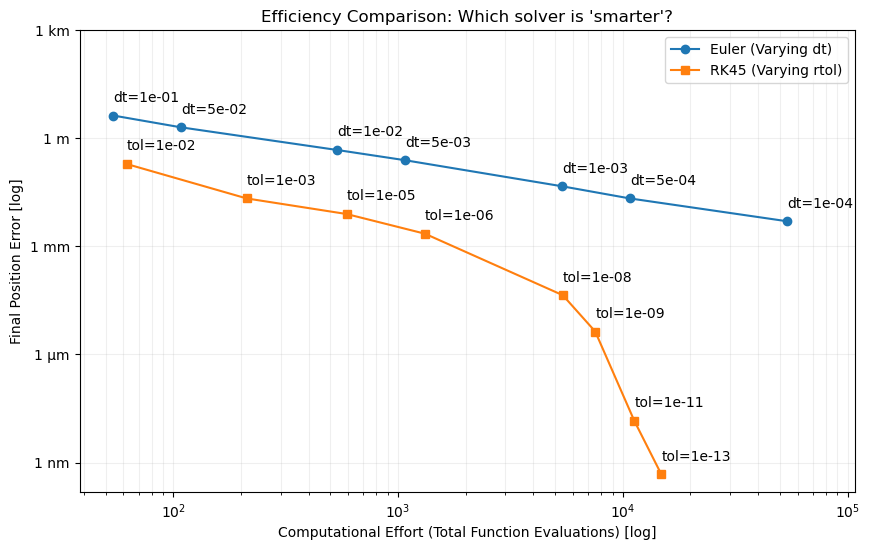

In [76]:
plot_convergence(*test_case)